In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))


In [2]:
# Standard library imports
import sys
from pathlib import Path

# Third-party scientific computing
import numpy as np
import pandas as pd

# Deep learning frameworks
import torch
import pytorch_lightning as pl

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.pipeline import Pipeline

# Local imports - data processing
from src.data_models.caravanify import Caravanify, CaravanifyConfig
from src.data_models.datamodule import HydroDataModule
from src.preprocessing.grouped import GroupedTransformer
from src.preprocessing.standard_scale import StandardScaleTransformer

# Local imports - models and evaluation
from src.models.TSMixer import LitTSMixer, TSMixerConfig
from src.models.evaluators import TSForecastEvaluator

# Append parent directory to path (if needed)
sys.path.append(str(Path().absolute().parent))

---

# Load the trained model

In [3]:
BENCHMARK_INPUT_LENGTH: int = 33
BENCHMARK_OUTPUT_LENGTH: int = 10
BENCHMARK_HIDDEN_SIZE: int = 127
BENCHMARK_DROPOUT: float = 0.2
BENCHMARK_NUM_LAYERS: int = 15
BENCHMARK_STATIC_EMBEDDING_SIZE: int = 16
BENCHMARK_LEARNING_RATE: float = 6.5e-5
BENCHMARK_FUSION_METHOD: str = "add"  # Options: "add" or "concat"

# similarity_based model configuration
CHALLENGER_INPUT_LENGTH: int = 256
CHALLENGER_OUTPUT_LENGTH: int = 10
CHALLENGER_HIDDEN_SIZE: int = 128
CHALLENGER_DROPOUT: float = 0.3
CHALLENGER_NUM_LAYERS: int = 13
CHALLENGER_STATIC_EMBEDDING_SIZE: int = 9
CHALLENGER_LEARNING_RATE: float = 2e-5


STATIC_FEATURES = [
    "gauge_id",
    "p_mean",
    "area",
    "ele_mt_sav",
    "high_prec_dur",
    "frac_snow",
    "high_prec_freq",
    "slp_dg_sav",
    "cly_pc_sav",
    "aridity_ERA5_LAND",
    "aridity_FAO_PM",
]

FORCING_FEATURES = [
    "snow_depth_water_equivalent_mean",
    "surface_net_solar_radiation_mean",
    "surface_net_thermal_radiation_mean",
    "potential_evaporation_sum_ERA5_LAND",
    "potential_evaporation_sum_FAO_PENMAN_MONTEITH",
    "temperature_2m_mean",
    "temperature_2m_min",
    "temperature_2m_max",
    "total_precipitation_sum",
]

TARGET = "streamflow"

benchmark_config = TSMixerConfig(
    input_len=BENCHMARK_INPUT_LENGTH,
    input_size=len(FORCING_FEATURES) + 1,  # +1 for target
    output_len=BENCHMARK_OUTPUT_LENGTH,
    static_size=len(STATIC_FEATURES) - 1,  # -1 for gauge_id
    future_input_size=len(FORCING_FEATURES),  # Add future forcing size
    hidden_size=BENCHMARK_HIDDEN_SIZE,
    static_embedding_size=BENCHMARK_STATIC_EMBEDDING_SIZE,
    num_layers=BENCHMARK_NUM_LAYERS,
    dropout=BENCHMARK_DROPOUT,
    learning_rate=BENCHMARK_LEARNING_RATE,
    group_identifier="gauge_id",  # Define GROUP_IDENTIFIER if necessary
    lr_scheduler_patience=5,  # Define LR_SCHEDULER_PATIENCE if necessary
    lr_scheduler_factor=0.5,  # Define LR_SCHEDULER_FACTOR if necessary
    fusion_method="add",  # Replace FUSION_METHOD with an appropriate value
)

challenger_config = TSMixerConfig(
    input_len=CHALLENGER_INPUT_LENGTH,
    input_size=len(FORCING_FEATURES) + 1,  # +1 for target
    output_len=CHALLENGER_OUTPUT_LENGTH,
    static_size=len(STATIC_FEATURES) - 1,  # -1 for gauge_id
    future_input_size=len(FORCING_FEATURES),  # Add future forcing size
    hidden_size=CHALLENGER_HIDDEN_SIZE,
    static_embedding_size=CHALLENGER_STATIC_EMBEDDING_SIZE,
    num_layers=CHALLENGER_NUM_LAYERS,
    dropout=CHALLENGER_DROPOUT,
    learning_rate=CHALLENGER_LEARNING_RATE,
    group_identifier="gauge_id",  # Define GROUP_IDENTIFIER if necessary
    lr_scheduler_patience=5,  # Define LR_SCHEDULER_PATIENCE if necessary
    lr_scheduler_factor=0.5,  # Define LR_SCHEDULER_FACTOR if necessary
    fusion_method="add",  # Replace FUSION_METHOD with an appropriate value
)

In [4]:
config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/shapefiles",
    # human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CA",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

ca_caravan = Caravanify(config)
ca_basins = ca_caravan.get_all_gauge_ids()

print(f"Found {len(ca_basins)} total CA basins")

ca_caravan.load_stations(ca_basins)

# Prepare data frames
ts_columns = FORCING_FEATURES + [TARGET]
static_columns = STATIC_FEATURES

ca_ts_data = ca_caravan.get_time_series()[
    ts_columns + ["date"] + ["gauge_id"]
]
ca_static_data = ca_caravan.get_static_attributes()[static_columns]

Found 78 total CA basins


In [5]:
feature_pipeline = Pipeline([("scaler", StandardScaleTransformer())])

target_pipeline = GroupedTransformer(
    Pipeline([("scaler", StandardScaleTransformer())]),
    columns=[TARGET],
    group_identifier="gauge_id",
    n_jobs=-1,
)

static_pipeline = Pipeline([("scaler", StandardScaleTransformer())])

preprocessing_config = {
    "features": {"pipeline": feature_pipeline},
    "target": {"pipeline": target_pipeline},
    "static_features": {"pipeline": static_pipeline},
}

In [6]:
STATIC_FEATURES = [col for col in static_columns]
FORCING_FEATURES = FORCING_FEATURES + [TARGET]

# Create data module for benchmark model
benchmark_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=BENCHMARK_INPUT_LENGTH,  # 33
    output_length=BENCHMARK_OUTPUT_LENGTH,
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.6,
    val_prop=0.2,
    test_prop=0.2,
    max_missing_pct=10,
    domain_id="CA",
    use_proportional_split=True,
)

# Create data module for similarity model
similarity_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=CHALLENGER_INPUT_LENGTH,  # 256
    output_length=CHALLENGER_OUTPUT_LENGTH,
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.6,
    val_prop=0.2,
    test_prop=0.2,
    max_missing_pct=10,
    domain_id="CA",
    use_proportional_split=True,
)

# Prepare both data modules
benchmark_data_module.prepare_data()
benchmark_data_module.setup()

similarity_data_module.prepare_data()
similarity_data_module.setup()

Original basins: 78
Retained basins: 44
Domain CA (source): Created 210504 valid sequences from 44 catchments
Domain CA (source): Created 68300 valid sequences from 44 catchments
Domain CA (source): Created 68925 valid sequences from 44 catchments
Original basins: 78
Retained basins: 44
Domain CA (source): Created 194980 valid sequences from 44 catchments
Domain CA (source): Created 56475 valid sequences from 44 catchments
Domain CA (source): Created 58062 valid sequences from 44 catchments


In [ ]:
benchmark = "/Users/cooper/Desktop/CAMELS-CH/experiments/GroupBased/saved_models/group_based_transfer/group1/tsmixer_group1_run0_20250313_134032.ckpt"
similarity_based_path = "/Users/cooper/Desktop/CAMELS-CH/experiments/GroupBased/saved_models/group_based_transfer/group1/tsmixer_group1_run0_20250313_174948.ckpt"

benchmark = LitTSMixer.load_from_checkpoint(benchmark, config=challenger_config)
similarity_based = LitTSMixer.load_from_checkpoint(
    similarity_based_path, config=challenger_config
)

# Create a dictionary mapping model names to (model, datamodule) tuples
models_and_datamodules = {
    "benchmark": (benchmark, similarity_data_module),
    "similarity_based": (similarity_based, similarity_data_module),
}

evaluator = TSForecastEvaluator(
    horizons=list(range(1, 11)),
    models_and_datamodules=models_and_datamodules,  # Use the new parameter
    trainer_kwargs={"accelerator": "cpu", "devices": 1},
)

In [21]:
# Run evaluation
results = evaluator.test_models()

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Testing benchmark...


/Users/cooper/Desktop/CAMELS-CH/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Original basins: 78
Retained basins: 44
Domain CA (source): Created 58062 valid sequences from 44 catchments


Testing: |          | 0/? [00:00<?, ?it/s]

...

Testing similarity_based...


/Users/cooper/Desktop/CAMELS-CH/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Original basins: 78
Retained basins: 44
Domain CA (source): Created 58062 valid sequences from 44 catchments


Testing: |          | 0/? [00:00<?, ?it/s]

Predictions shape: torch.Size([58062, 10])
Observations shape: torch.Size([58062, 10])
Number of basin_ids: 58062
Number of input_end_dates: 58062
Configured horizons: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Evaluating results with shape: preds=(58062, 10), obs=(58062, 10), basin_ids=(58062,)


In [22]:
results["similarity_based"].keys()

dict_keys(['df', 'metrics', 'basin_metrics', 'datamodule'])

In [23]:
def filter_growing_season(eval_results):
    """
    Filter evaluation results to include only data from the growing season (April to October).
    
    Args:
        eval_results: Dictionary containing evaluation results with a 'df' key
        
    Returns:
        Dictionary with filtered dataframe and original metrics
    """
    # Create a copy of the results to avoid modifying the original
    filtered_results = eval_results.copy()
    
    # Extract the dataframe
    df = eval_results['df'].copy()
    
    # Ensure date column is datetime
    df['date'] = pd.to_datetime(df['date'])
    
    # Filter for growing season (April to October)
    growing_season_df = df[(df['date'].dt.month >= 4) & (df['date'].dt.month < 10)]
    
    # Replace the dataframe in the results
    filtered_results['df'] = growing_season_df
    
    return filtered_results

seasonal_benchmark_results = filter_growing_season(results["benchmark"])
seasonal_similarity_based_results = filter_growing_season(results["similarity_based"])

seasonal_benchmark_results["metrics"] = evaluator._calculate_overall_metrics(seasonal_benchmark_results["df"])
seasonal_similarity_based_results["metrics"] = evaluator._calculate_overall_metrics(seasonal_similarity_based_results["df"])

seasonal_benchmark_results["basin_metrics"] = evaluator._calculate_basin_metrics(seasonal_benchmark_results["df"])
seasonal_similarity_based_results["basin_metrics"] = evaluator._calculate_basin_metrics(seasonal_similarity_based_results["df"])

seasonal_results = {}
seasonal_results["benchmark"] = seasonal_benchmark_results
seasonal_results["similarity_based"] = seasonal_similarity_based_results

evaluator.results = seasonal_results

In [24]:
evaluator.summarize_metrics(seasonal_similarity_based_results["basin_metrics"], per_basin=True)

MSE       MAE       NSE      RMSE
basin_id horizon                                        
CA_15013 1        0.269858  0.340694  0.885314  0.519479
         2        0.405371  0.414445  0.827890  0.636688
         3        0.503175  0.456677  0.786704  0.709348
         4        0.558997  0.475420  0.763374  0.747661
         5        0.591112  0.489603  0.750103  0.768838
...                    ...       ...       ...       ...
CA_17462 6        0.024688  0.103436  0.614202  0.157124
         7        0.027760  0.112158  0.566555  0.166614
         8        0.031273  0.121760  0.512174  0.176843
         9        0.034082  0.129667  0.468887  0.184612
         10       0.036322  0.135180  0.434516  0.190584

[440 rows x 4 columns]

In [25]:
evaluator.summarize_metrics(seasonal_benchmark_results["basin_metrics"], per_basin=True)

MSE       MAE       NSE      RMSE
basin_id horizon                                        
CA_15013 1        0.298709  0.350981  0.873053  0.546543
         2        0.459734  0.428003  0.804809  0.678037
         3        0.600013  0.479981  0.745654  0.774605
         4        0.700955  0.512182  0.703284  0.837230
         5        0.780041  0.551326  0.670232  0.883199
...                    ...       ...       ...       ...
CA_17462 6        0.027076  0.101667  0.576890  0.164547
         7        0.029948  0.109614  0.532390  0.173055
         8        0.035365  0.121331  0.448351  0.188056
         9        0.039270  0.130571  0.388035  0.198166
         10       0.041583  0.135795  0.352610  0.203920

[440 rows x 4 columns]

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': '10-day Forecast for CA_16135'}, xlabel='Date', ylabel='Streamflow'>)

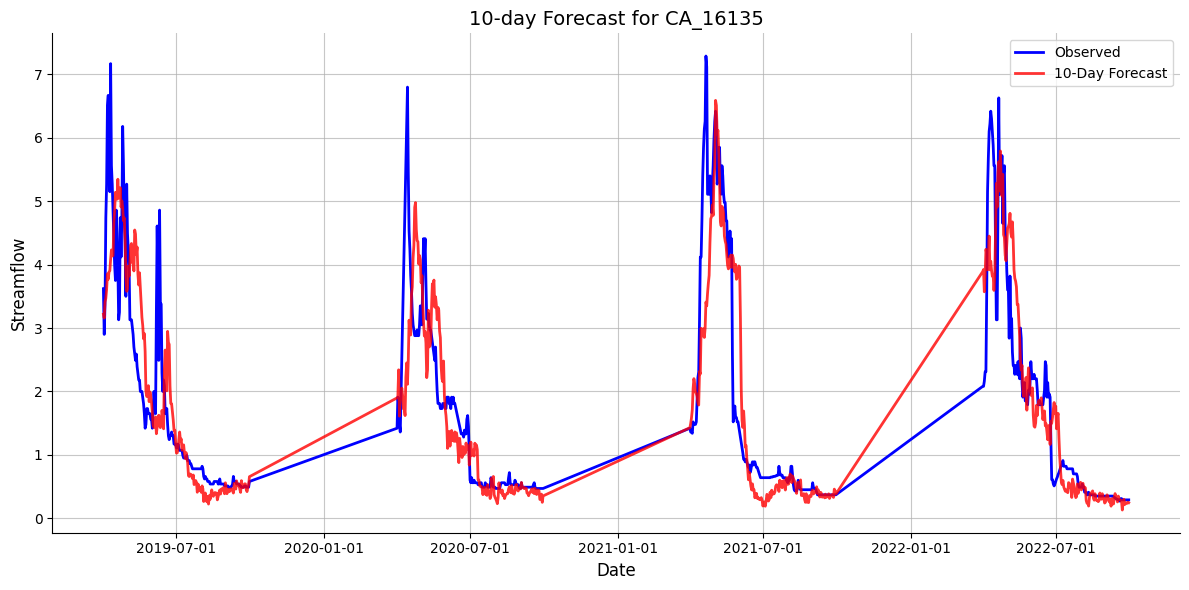

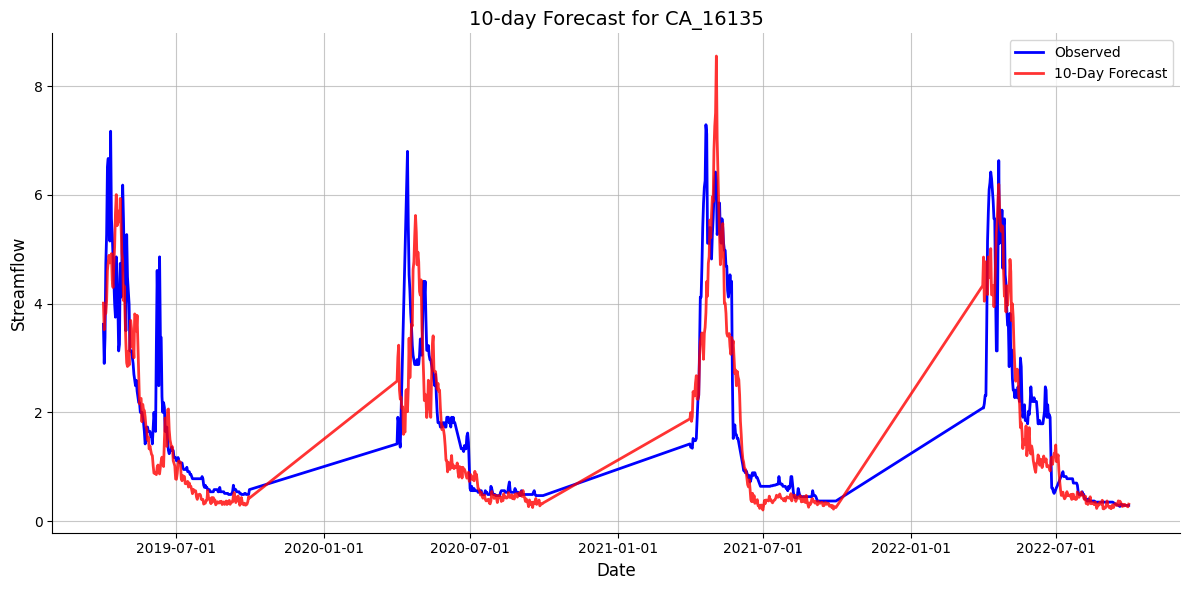

In [26]:
evaluator.plot_rolling_forecast(
    "similarity_based",
    horizon=10, 
    group_identifier="CA_16135"
)

evaluator.plot_rolling_forecast(
    "benchmark",
    horizon=10, 
    group_identifier="CA_16135"
)


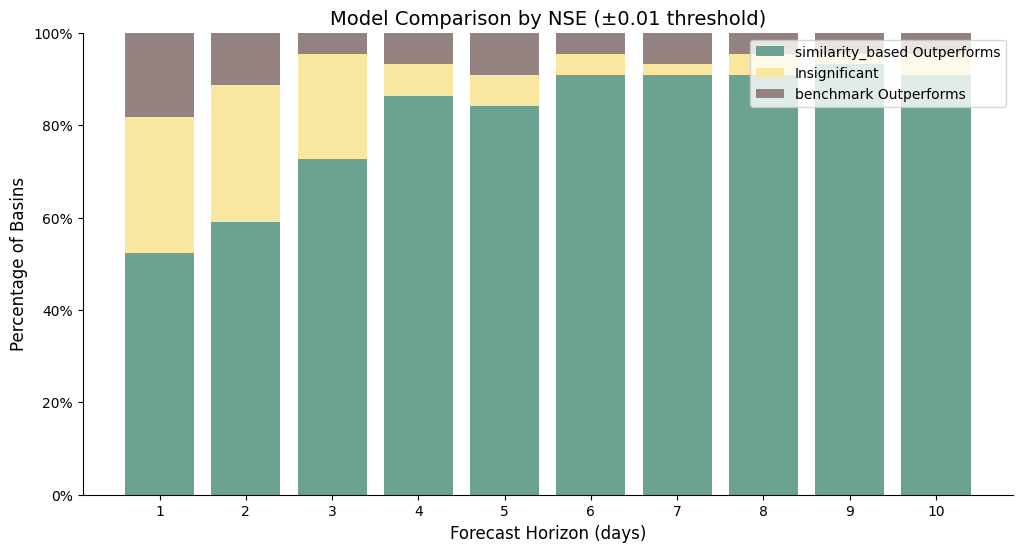

{'avg_better': np.float64(81.13636363636363), 'avg_insignificant': np.float64(11.363636363636363), 'avg_worse': np.float64(7.5), 'best_horizon': np.int64(9), 'best_horizon_pct': np.float64(93.18181818181817), 'worst_horizon': np.int64(1), 'worst_horizon_pct': np.float64(52.27272727272727)}


In [34]:
comparison_results = evaluator.compare_models("benchmark", "similarity_based", metric="NSE", threshold=0.01)

# Plot the stacked bar chart of the comparison results
fig, ax = evaluator.plot_model_comparison(comparison_results)
plt.show()

# Optionally, print a summary of the comparison statistics
summary = evaluator.summarize_comparison(comparison_results)
print(summary)

In [28]:
# Pritn all available methods for the evaluator
print("Available methods for the evaluator:")
for method_name in dir(evaluator):
    if callable(getattr(evaluator, method_name)) and not method_name.startswith("__"):
        print(method_name)

Available methods for the evaluator:
_calculate_basin_metrics
_calculate_metrics
_calculate_overall_metrics
_calculate_performance_comparison
_prepare_evaluation_dataframe
analyze_basin_performance
calculate_mae
calculate_mse
calculate_nse
calculate_rmse
compare_models
evaluate
flatten_basin_metrics
identify_improved_basins
plot_delta_vs_benchmark
plot_model_comparison
plot_nse_comparison
plot_rolling_forecast
register_model
summarize_comparison
summarize_metrics
test_models
test_specific_model


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Distribution of NSE Values by Horizon'}, xlabel='Forecast Horizon (days)', ylabel='NSE Value'>)

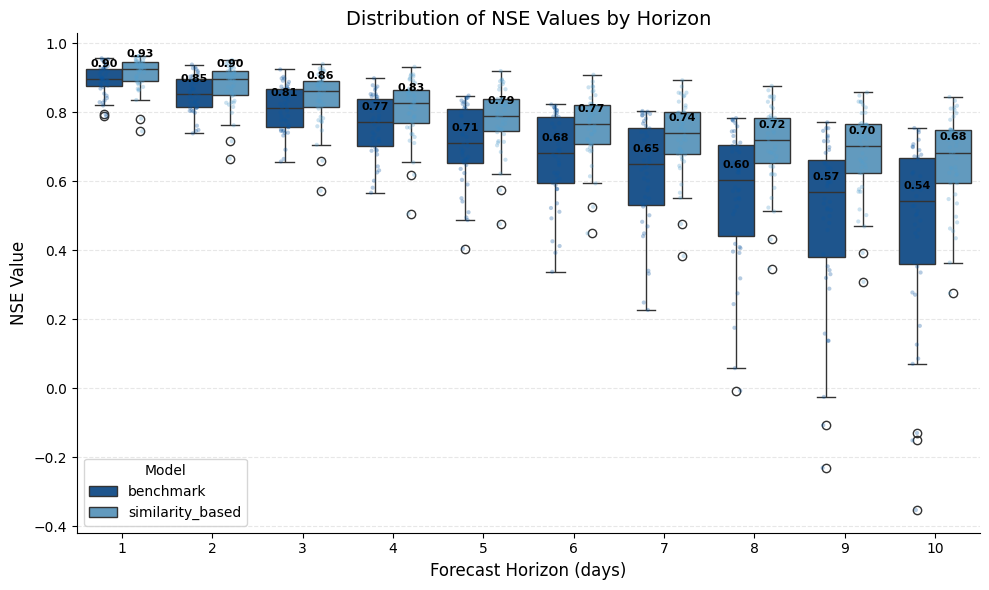

In [29]:
evaluator.plot_nse_comparison(
    "benchmark",
    "similarity_based",
    metric="NSE",
    plot_type="box",
    violin=False,
    figsize=(10, 6),
)

In [30]:
# Get basins that improved or worsened
basin_analysis = evaluator.identify_improved_basins(
    "benchmark", "similarity_based", metric="NSE"
)
improved_basins = basin_analysis["improved"]
worsened_basins = basin_analysis["worsened"]

In [33]:
worsened_basins

[]

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Model Performance Comparison by Horizon (NSE)'}, xlabel='Forecast Horizon (days)', ylabel='Average NSE'>)

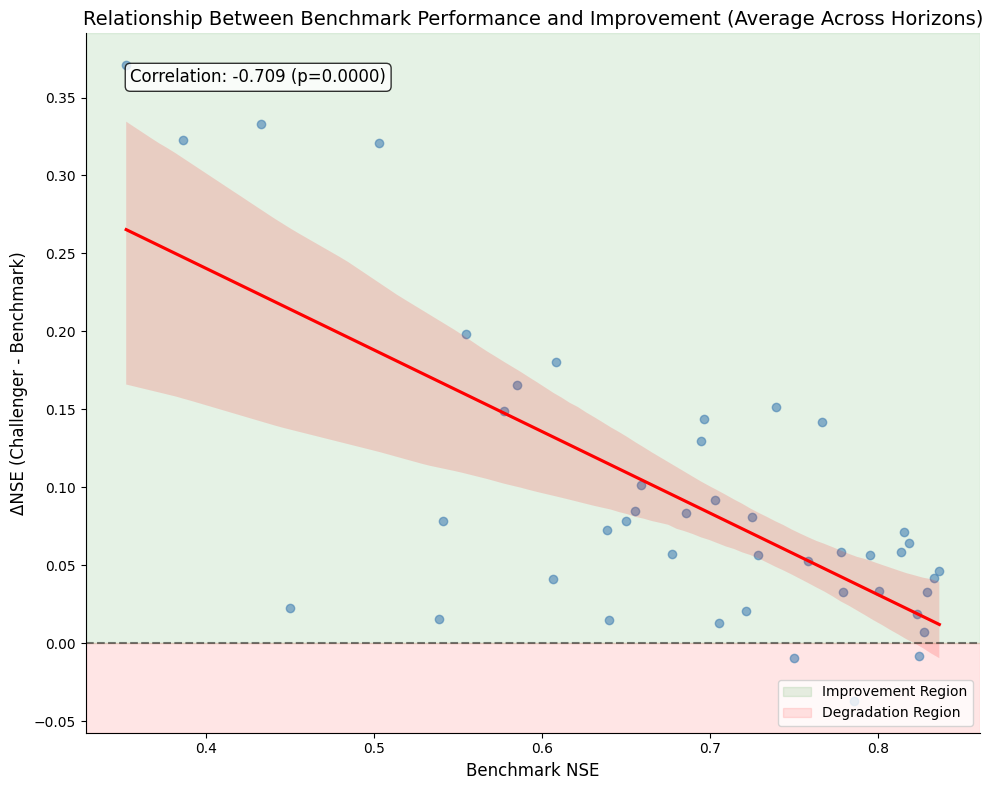

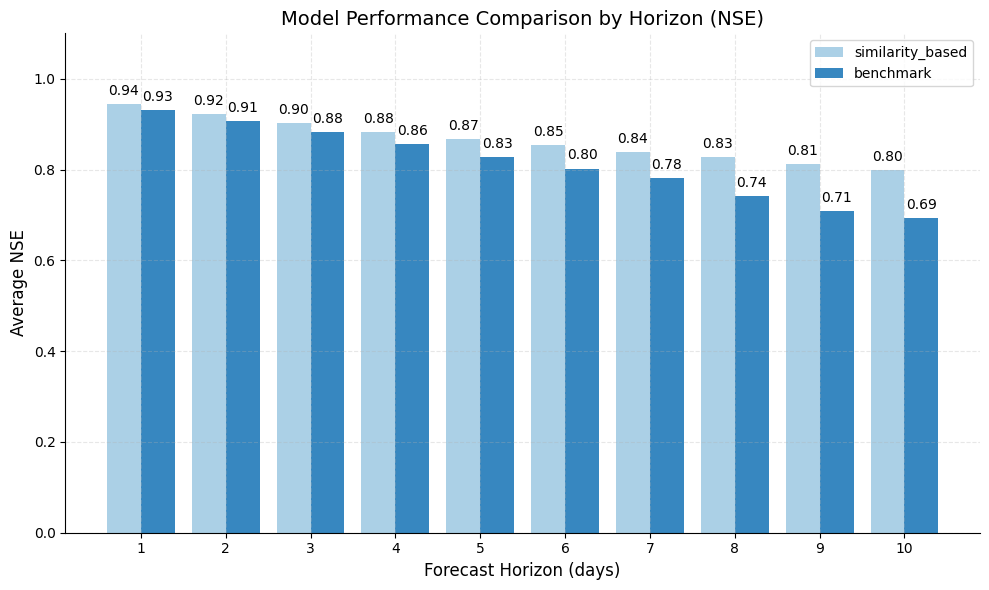

In [32]:
# Plot the relationship between benchmark performance and improvement
evaluator.plot_delta_vs_benchmark("benchmark", "similarity_based", metric="NSE")

# Create boxplot comparison instead of bar chart
evaluator.plot_nse_comparison("benchmark", "similarity_based", metric="NSE", figsize=(10,6))